In [31]:
import os, glob, csv, math
import numpy as np
import torch
from PIL import Image
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm
from IPython.display import display, Image as IPyImage

In [14]:
from transformers import AutoImageProcessor, AutoModelForDepthEstimation
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained("Intel/zoedepth-nyu-kitti")
model = AutoModelForDepthEstimation.from_pretrained(
    "Intel/zoedepth-nyu-kitti",
    torch_dtype=torch.float32
).to(device).eval()


In [ ]:


# For an optional preview later:
import matplotlib.pyplot as plt

# Show numpy prints nicely
np.set_printoptions(suppress=True, precision=4)


In [23]:
# Change this to your folder that contains the 3 images
INPUT_DIR = "outputs_sam2"  
OUTPUT_DIR = os.path.join(INPUT_DIR, "zoe_outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

exts = ("*.jpg","*.jpeg","*.png","*.bmp","*.webp","*.tif","*.tiff")
image_paths = []
for e in exts:
    image_paths += glob.glob(os.path.join(INPUT_DIR, e))
image_paths = sorted(image_paths)

if not image_paths:
    raise FileNotFoundError(f"No images found in: {INPUT_DIR}")

print(f"Found {len(image_paths)} image(s):")
for p in image_paths:
    print(" •", os.path.basename(p))


Found 3 image(s):
 • image1_overlay.jpg
 • image2_overlay.jpg
 • images_overlay.jpg


In [ ]:
def postprocess_depth(outputs, original_sizes, remove_padding=True):
    """
    Returns a list of dicts with 'predicted_depth' resized to each original (H, W).
    Works across Transformers versions.
    """
    try:
        if remove_padding:
            # When do_pad=True (default), ZoeDepth requires source_sizes
            return processor.post_process_depth_estimation(
                outputs,
                source_sizes=original_sizes,    
                target_sizes=original_sizes      
            )
        else:
            # If you explicitly don't want padding removal
            return processor.post_process_depth_estimation(
                outputs,
                target_sizes=original_sizes,
                do_remove_padding=False
            )
    except TypeError:
        # Older versions: fall back to source_sizes only
        return processor.post_process_depth_estimation(
            outputs,
            source_sizes=original_sizes
        )



In [12]:
def to_device_and_dtype(batchfeature, model, device):
    out = {}
    for k, v in batchfeature.items():
        if hasattr(v, "to"):  # tensor
            if k == "pixel_values":
                out[k] = v.to(device=device, dtype=model.dtype)  # match model dtype (fp16 on GPU)
            else:
                out[k] = v.to(device=device)
        else:
            out[k] = v
    return out

In [24]:
FLIP_AVG = False
summary_rows = []

for path in image_paths:
    im = Image.open(path).convert("RGB")
    inputs = processor(images=im, return_tensors="pt")
    inputs = to_device_and_dtype(inputs, model, device)   # from the previous dtype fix

    with torch.no_grad():
        outputs = model(**inputs)
        if FLIP_AVG:
            flipped = torch.flip(inputs["pixel_values"], dims=[3])
            outputs_f = model(pixel_values=flipped)

    processed = postprocess_depth(outputs, [(im.height, im.width)])  # <-- passes source_sizes now
    depth_m = processed[0]["predicted_depth"].cpu().numpy().astype(np.float32)

    if FLIP_AVG:
        processed_f = postprocess_depth(outputs_f, [(im.height, im.width)])
        depth_f = processed_f[0]["predicted_depth"].cpu().numpy().astype(np.float32)
        depth_m = 0.5 * (depth_m + np.fliplr(depth_f))

    stem = os.path.splitext(os.path.basename(path))[0]
    out_stem = os.path.join(OUTPUT_DIR, stem)
    save_depth_visuals(depth_m, out_stem)

    d = depth_m.copy(); d[~np.isfinite(d)] = np.nan
    summary_rows.append([stem, float(np.nanmin(d)), float(np.nanmedian(d)), float(np.nanmax(d))])

# CSV summary
csv_path = os.path.join(OUTPUT_DIR, "summary.csv")
with open(csv_path, "w", newline="") as f:
    w = csv.writer(f); w.writerow(["image","min_m","median_m","max_m"]); w.writerows(summary_rows)

print(f"Done. Saved outputs to: {OUTPUT_DIR}")
print(f"CSV summary: {csv_path}")

Done. Saved outputs to: outputs_sam2/zoe_outputs
CSV summary: outputs_sam2/zoe_outputs/summary.csv


In [32]:
# If GLOBAL_SCALE=True, every colorbar uses the same meters range (good for comparisons).
# If False, each image auto-picks its own [1%, 99%] range (usually prettier).
GLOBAL_SCALE = True

# Compute a global [vmin, vmax] from all depth maps if you want consistent scaling.
vmin_global = vmax_global = None
if GLOBAL_SCALE:
    vmins, vmaxs = [], []
    for img_path in image_paths:
        stem = os.path.splitext(os.path.basename(img_path))[0]
        d = np.load(os.path.join(OUTPUT_DIR, stem + "_depth_m.npy")).astype(np.float32)
        d[~np.isfinite(d)] = np.nan
        vmins.append(np.nanpercentile(d, 1))
        vmaxs.append(np.nanpercentile(d, 99))
    vmin_global = float(np.nanmin(vmins))
    vmax_global = float(np.nanmax(vmaxs))
    print(f"Using GLOBAL color scale: vmin={vmin_global:.3f} m, vmax={vmax_global:.3f} m")


Using GLOBAL color scale: vmin=1.060 m, vmax=2.348 m


In [ ]:
matplotlib.rcParams["figure.dpi"] = 120  # keep if you like

def save_and_show_side_by_side(
    img_path, depth_path, out_dir,
    vmin=None, vmax=None, show_inline=True, dpi=150
):
    stem = os.path.splitext(os.path.basename(img_path))[0]
    rgb = Image.open(img_path).convert("RGB")
    d = np.load(depth_path).astype(np.float32)
    d[~np.isfinite(d)] = np.nan

    # choose visualization range
    if vmin is None or vmax is None:
        vmin = float(np.nanpercentile(d, 1))
        vmax = float(np.nanpercentile(d, 99))
    if vmax <= vmin:
        vmax = vmin + 1e-3

    # side-by-side figure with a meter colorbar
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(rgb)
    axes[0].set_title("Input")
    axes[0].axis("off")

    im = axes[1].imshow(d, vmin=vmin, vmax=vmax, cmap="viridis")
    cb = plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    cb.set_label("meters")
    axes[1].set_title("ZoeDepth (metric)")
    axes[1].axis("off")

    out_path = os.path.join(out_dir, f"{stem}_side_by_side.png")
    fig.savefig(out_path, bbox_inches="tight", dpi=dpi)
    if show_inline:
        plt.show()
    else:
        plt.close(fig)

    print(f"[{stem}] vmin={vmin:.3f} m, vmax={vmax:.3f} m | saved:", os.path.basename(out_path))
    return out_path


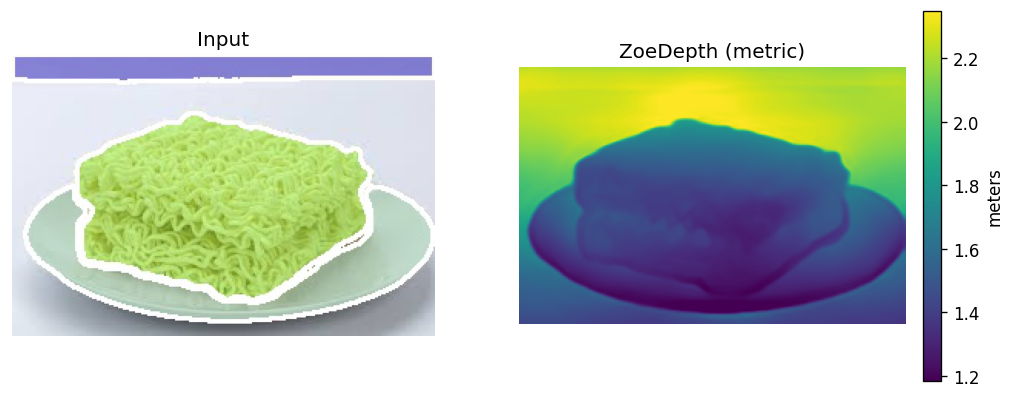

[image1_overlay] vmin=1.185 m, vmax=2.348 m | saved: image1_overlay_side_by_side.png


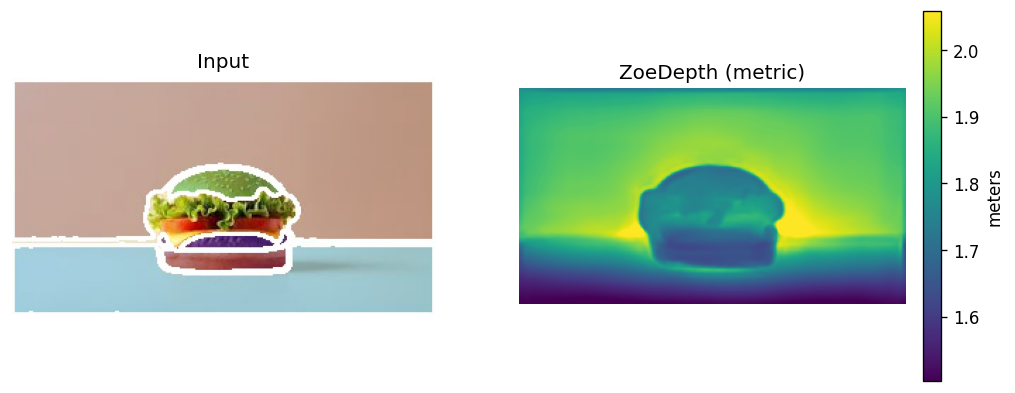

[image2_overlay] vmin=1.503 m, vmax=2.058 m | saved: image2_overlay_side_by_side.png


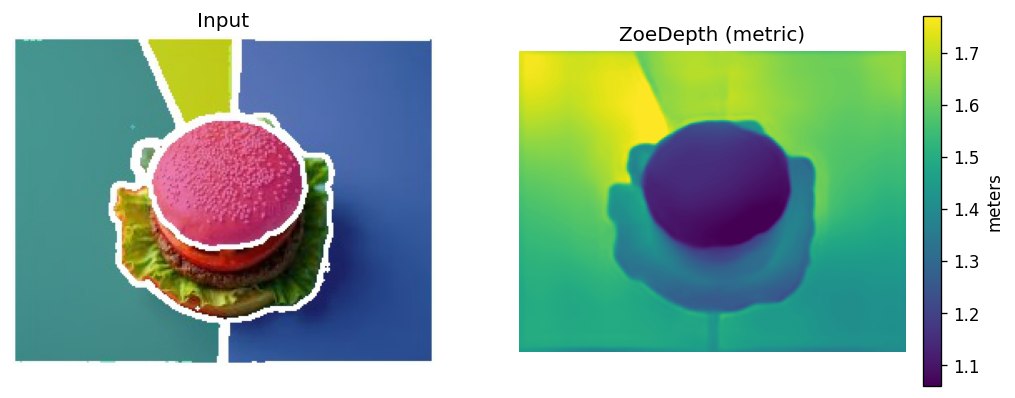

[images_overlay] vmin=1.060 m, vmax=1.770 m | saved: images_overlay_side_by_side.png


In [37]:
# Optional: set a global meters range for consistent color scale across images
GLOBAL_SCALE = False
vmin_global = vmax_global = None
if GLOBAL_SCALE:
    vmins, vmaxs = [], []
    for img_path in image_paths:
        stem = os.path.splitext(os.path.basename(img_path))[0]
        d = np.load(os.path.join(OUTPUT_DIR, stem + "_depth_m.npy")).astype(np.float32)
        d[~np.isfinite(d)] = np.nan
        vmins.append(np.nanpercentile(d, 1))
        vmaxs.append(np.nanpercentile(d, 99))
    vmin_global = float(np.nanmin(vmins))
    vmax_global = float(np.nanmax(vmaxs))
    print(f"GLOBAL color scale: vmin={vmin_global:.3f} m, vmax={vmax_global:.3f} m")

for img_path in image_paths:
    stem = os.path.splitext(os.path.basename(img_path))[0]
    depth_path = os.path.join(OUTPUT_DIR, stem + "_depth_m.npy")
    if not os.path.exists(depth_path):
        print(f"Missing depth for: {stem} (skipping)")
        continue

    save_and_show_side_by_side(
        img_path,
        depth_path,
        OUTPUT_DIR,
        vmin=vmin_global if GLOBAL_SCALE else None,
        vmax=vmax_global if GLOBAL_SCALE else None,
        show_inline=True
    )
